Data types of columns:
FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                    

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by CatBoost: Index(['URLSimilarityIndex', 'HasHiddenFields'], dtype='object')
Running time: 48.65457 seconds
CatBoost Accuracy (Selected Features): 0.9964941545682015
CatBoost ROC-AUC (Selected Features): 0.9982525620681217
CatBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     30151
           1       0.99      1.00      1.00     40588

    accuracy                           1.00     70739
   macro avg       1.00      1.00      1.00     70739
weighted avg       1.00      1.00      1.00     70739



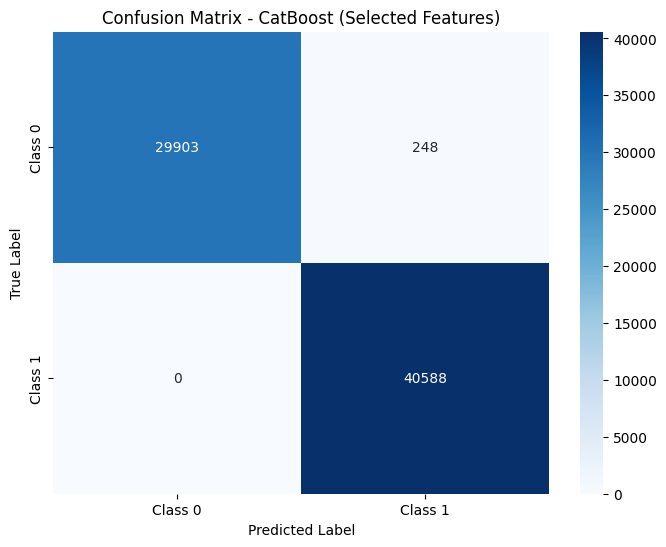

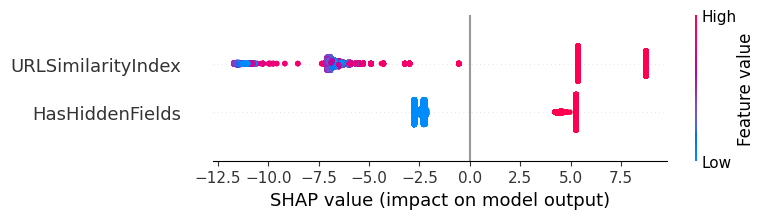

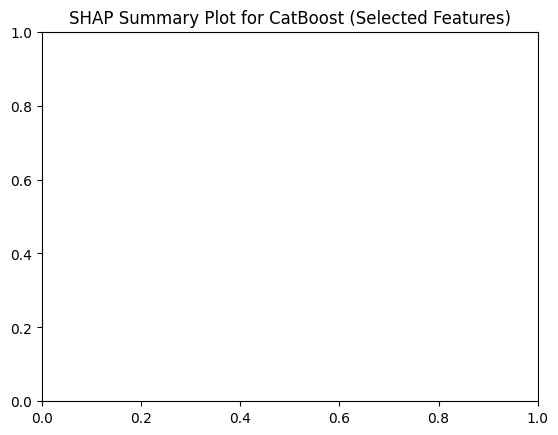

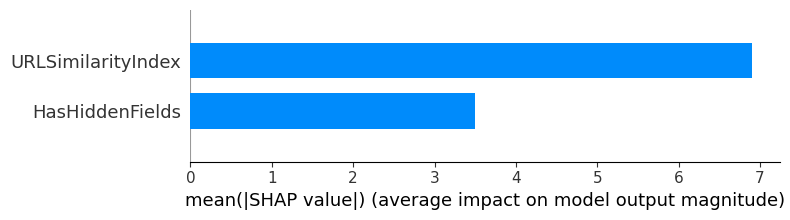

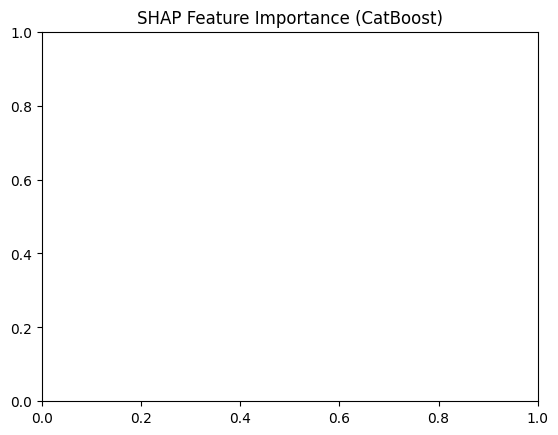

<Figure size 640x480 with 0 Axes>

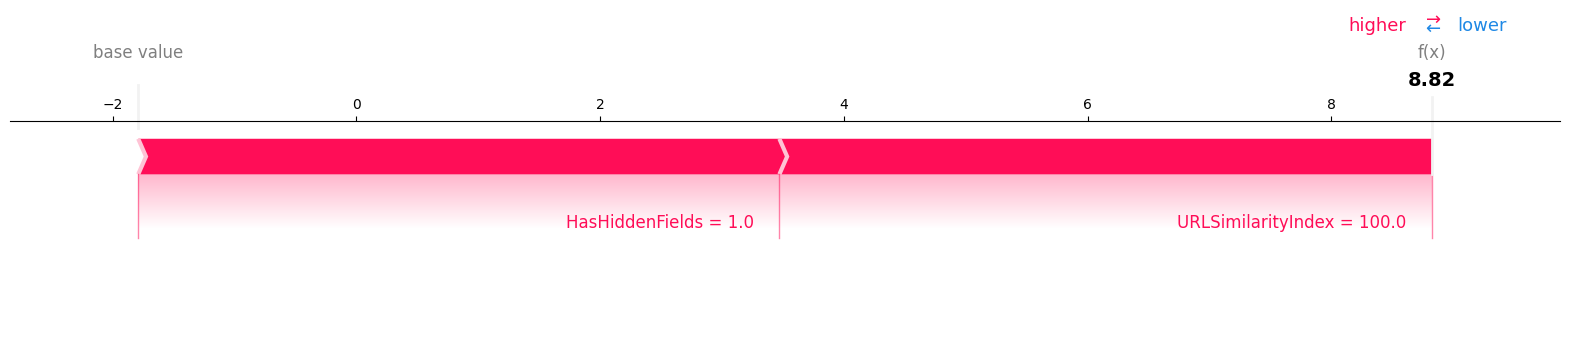

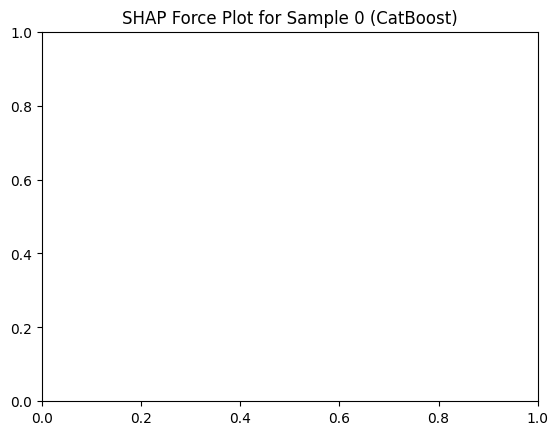

In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_235795_54.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using CatBoost
# Train an initial CatBoost model to get feature importances
catboost_initial_model = CatBoostClassifier(random_state=42, silent=True)
catboost_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on CatBoost feature importances
feature_selector = SelectFromModel(catboost_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by CatBoost: {selected_features}")

# Step 6: Train final CatBoost model with selected features
catboost_model = CatBoostClassifier(random_state=42, silent=True)
catboost_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = catboost_model.predict(X_test_selected)
y_proba = catboost_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
catboost_accuracy = accuracy_score(y_test, y_pred)
catboost_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")


print(f"CatBoost Accuracy (Selected Features): {catboost_accuracy}")
print(f"CatBoost ROC-AUC (Selected Features): {catboost_roc_auc}")
print("CatBoost Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - CatBoost (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for CatBoost
# Create a SHAP explainer for CatBoost model
explainer = shap.TreeExplainer(catboost_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for CatBoost (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (CatBoost)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (CatBoost)")
plt.show()


Data types of columns:
qty_dot_url             int64
qty_hyphen_url          int64
qty_underline_url       int64
qty_slash_url           int64
qty_questionmark_url    int64
                        ...  
qty_redirects           int64
url_google_index        int64
domain_google_index     int64
url_shortened           int64
phishing                int64
Length: 112, dtype: object
Before SMOTE: Class distribution in y_train: 0    54320
1    36468
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: 0    54320
1    54320
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by CatBoost: Index(['qty_slash_url', 'length_url', 'qty_dot_domain', 'qty_vowels_domain',
       'domain_length', 'qty_hyphen_directory', 'qty_slash_directory',
       'directory_length', 'file_length', 'time_response', 'asn_ip',
       'time_domain_activation', 'time_domain_expiration', 'qty_ip_resolved',
       'qty_nameservers', 'qty_mx_servers', 'ttl_hostname',
       'tls_ssl_certificate', 'qty_redirects'],
      dtype='object')
Running time: 39.34202 seconds
CatBoost Accuracy (Selected Features): 0.9729632485222308
CatBoost ROC-AUC (Selected Features): 0.9958425861926936
CatBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     23226
           1       0.96      0.97      0.97     15684

    accuracy                           0.97     38910
   macro avg       0.97      0.97      0.97     38910
weighted avg       0.97      0.97      0.97     38910



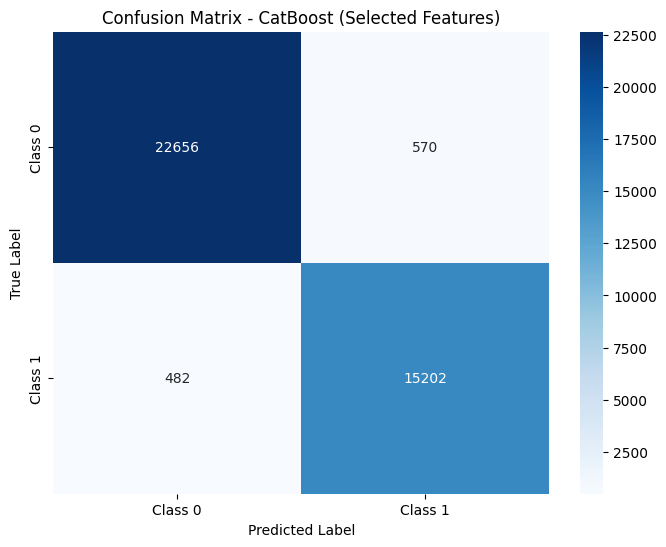

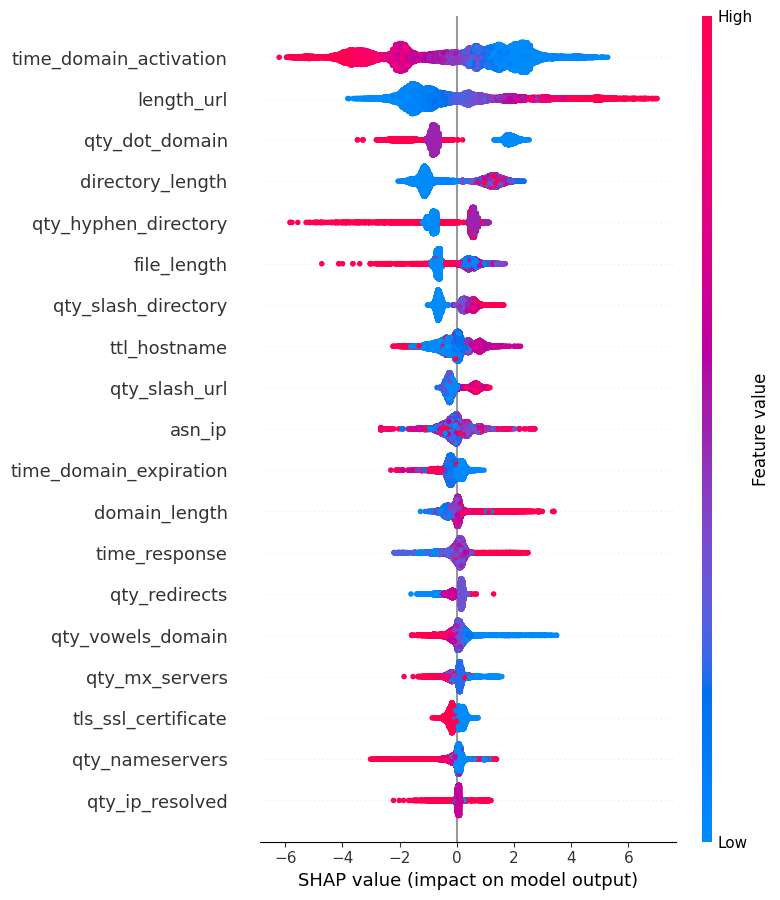

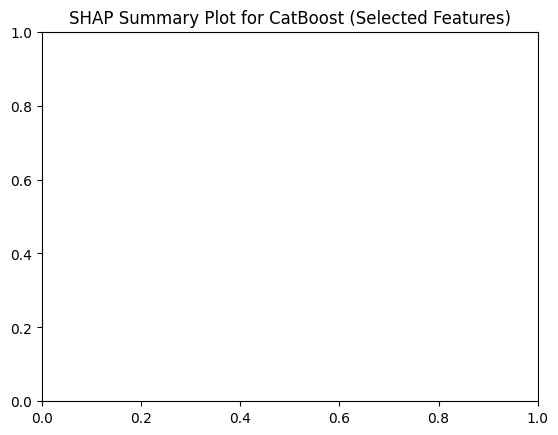

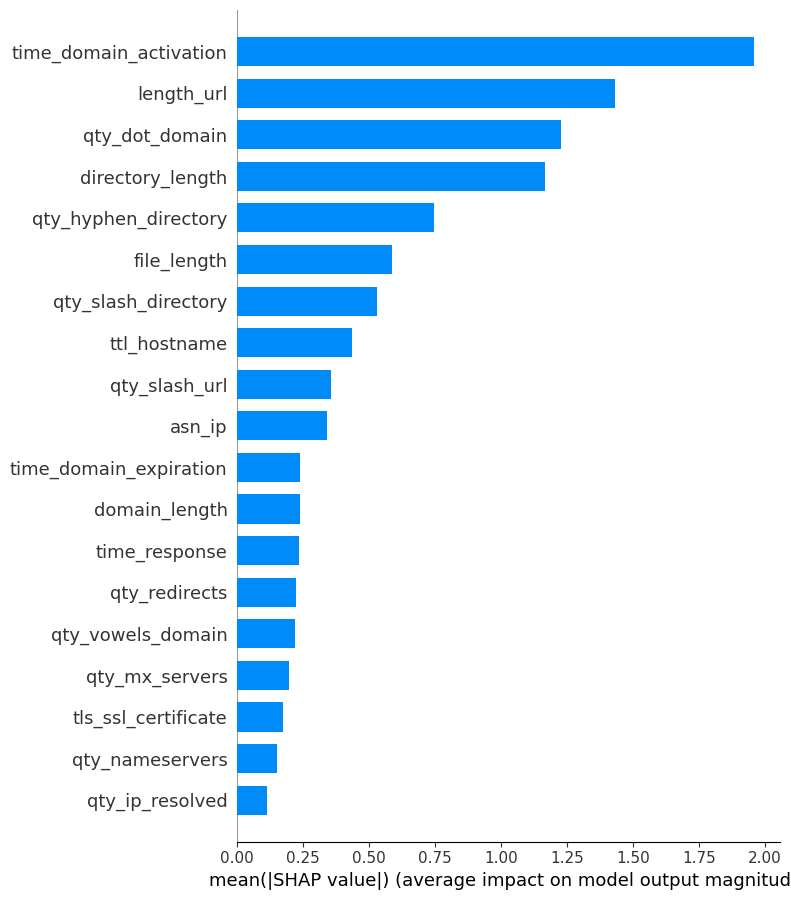

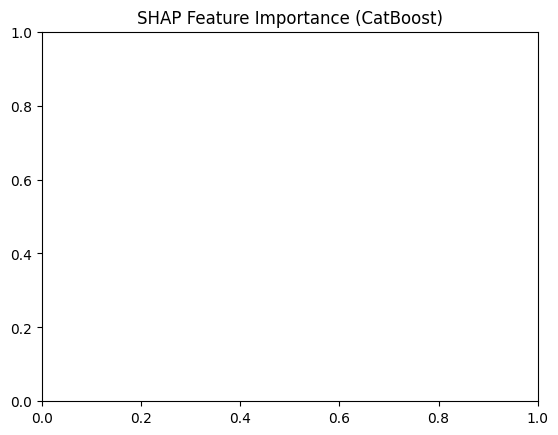

<Figure size 640x480 with 0 Axes>

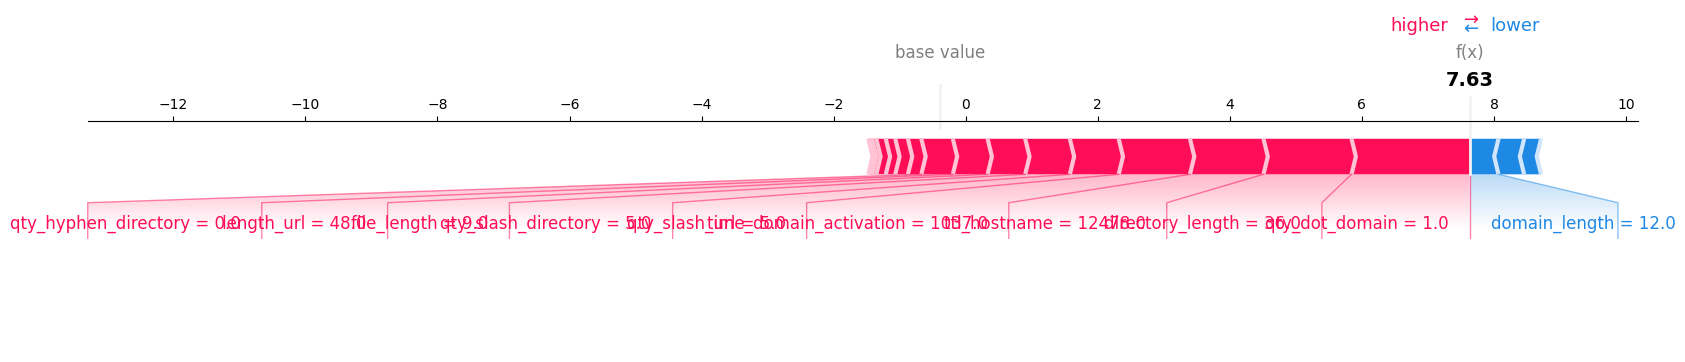

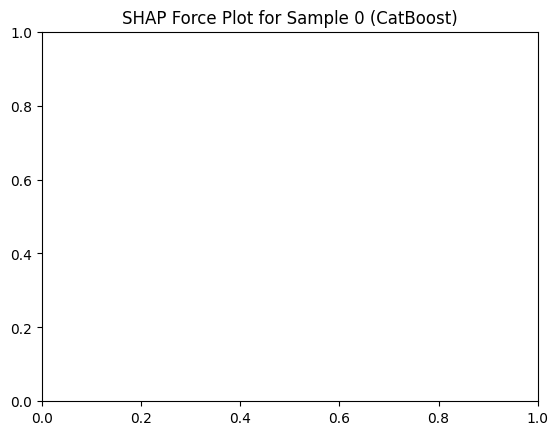

In [32]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_129K112.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using CatBoost
# Train an initial CatBoost model to get feature importances
catboost_initial_model = CatBoostClassifier(random_state=42, silent=True)
catboost_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on CatBoost feature importances
feature_selector = SelectFromModel(catboost_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by CatBoost: {selected_features}")

# Step 6: Train final CatBoost model with selected features
catboost_model = CatBoostClassifier(random_state=42, silent=True)
catboost_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = catboost_model.predict(X_test_selected)
y_proba = catboost_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
catboost_accuracy = accuracy_score(y_test, y_pred)
catboost_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")


print(f"CatBoost Accuracy (Selected Features): {catboost_accuracy}")
print(f"CatBoost ROC-AUC (Selected Features): {catboost_roc_auc}")
print("CatBoost Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - CatBoost (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for CatBoost
# Create a SHAP explainer for CatBoost model
explainer = shap.TreeExplainer(catboost_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for CatBoost (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (CatBoost)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (CatBoost)")
plt.show()


Data types of columns:
url_length        int64
n_dots            int64
n_hypens          int64
n_underline       int64
n_slash           int64
n_questionmark    int64
n_equal           int64
n_at              int64
n_and             int64
n_exclamation     int64
n_space           int64
n_tilde           int64
n_comma           int64
n_plus            int64
n_asterisk        int64
n_hastag          int64
n_dollar          int64
n_percent         int64
n_redirection     int64
phishing          int64
dtype: object
Before SMOTE: Class distribution in y_train: 0    44741
1    25312
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: 0    44741
1    44741
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by CatBoost: Index(['url_length', 'n_dots', 'n_hypens', 'n_slash', 'n_redirection'], dtype='object')
Running time: 39.84469 seconds
CatBoost Accuracy (Selected Features): 0.8788302691180389
CatBoost ROC-AUC (Selected Features): 0.9559864654037176
CatBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.94      0.86      0.90     18974
           1       0.79      0.91      0.85     11050

    accuracy                           0.88     30024
   macro avg       0.87      0.89      0.87     30024
weighted avg       0.89      0.88      0.88     30024



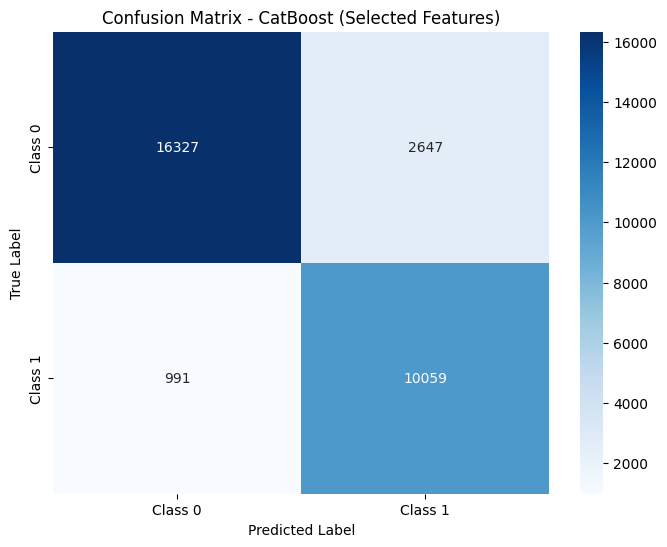

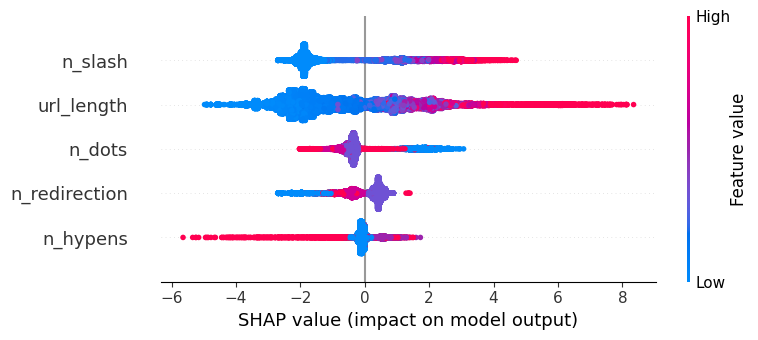

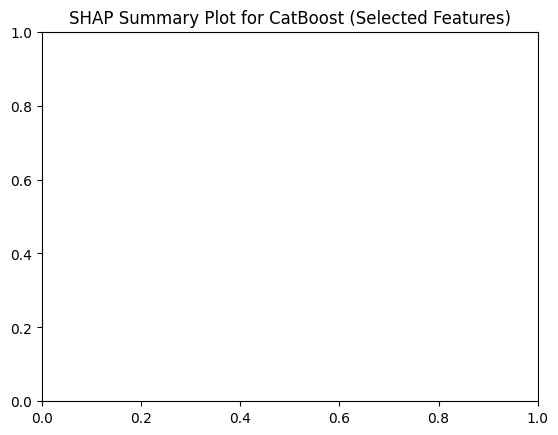

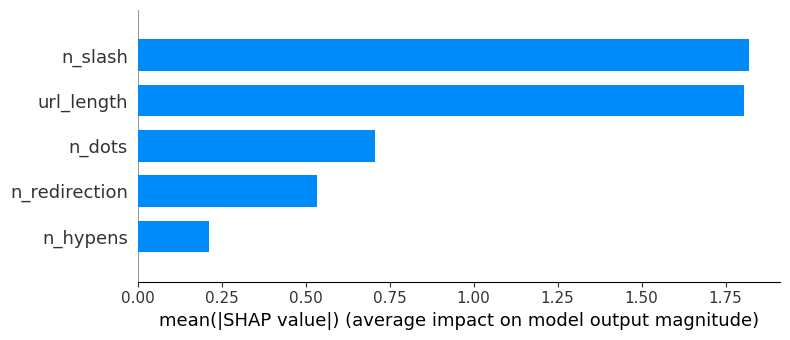

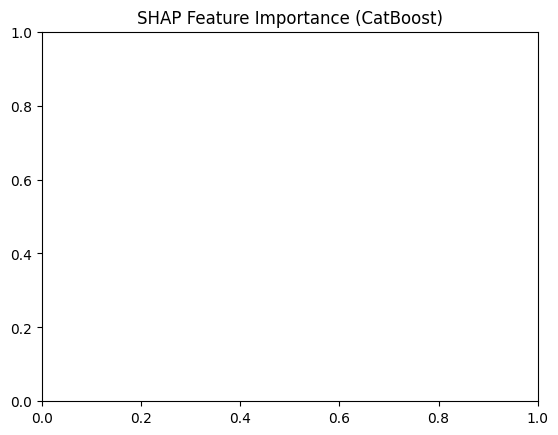

<Figure size 640x480 with 0 Axes>

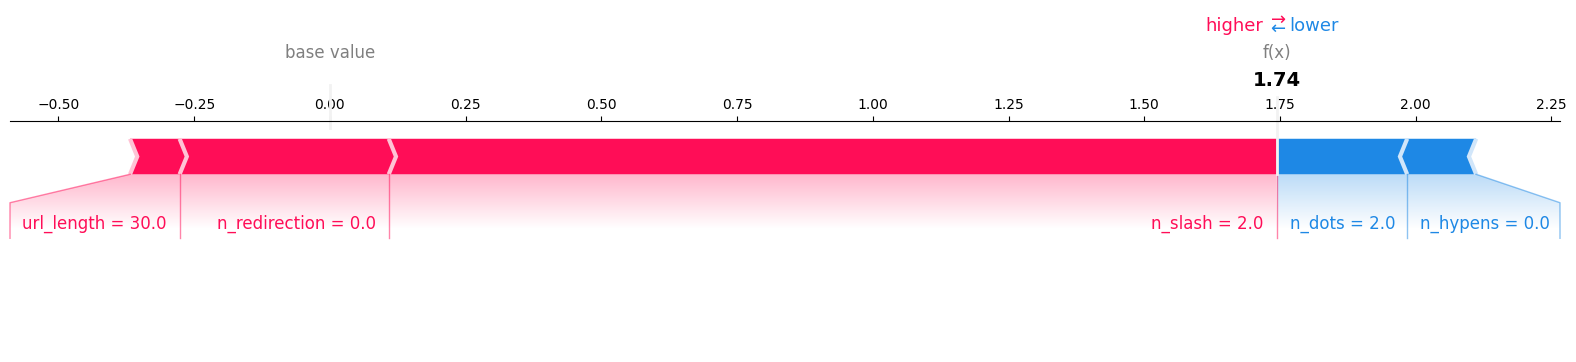

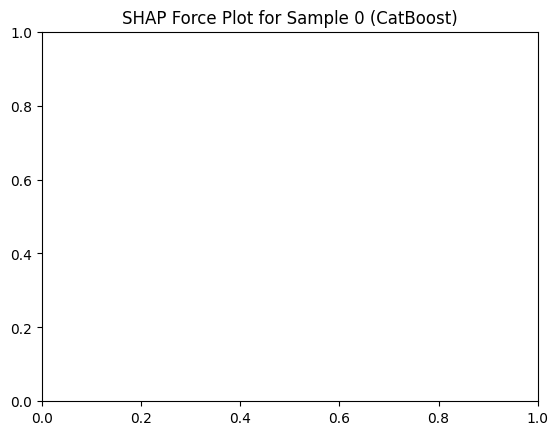

In [34]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_100K20.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using CatBoost
# Train an initial CatBoost model to get feature importances
catboost_initial_model = CatBoostClassifier(random_state=42, silent=True)
catboost_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on CatBoost feature importances
feature_selector = SelectFromModel(catboost_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by CatBoost: {selected_features}")

# Step 6: Train final CatBoost model with selected features
catboost_model = CatBoostClassifier(random_state=42, silent=True)
catboost_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = catboost_model.predict(X_test_selected)
y_proba = catboost_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
catboost_accuracy = accuracy_score(y_test, y_pred)
catboost_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")


print(f"CatBoost Accuracy (Selected Features): {catboost_accuracy}")
print(f"CatBoost ROC-AUC (Selected Features): {catboost_roc_auc}")
print("CatBoost Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - CatBoost (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for CatBoost
# Create a SHAP explainer for CatBoost model
explainer = shap.TreeExplainer(catboost_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for CatBoost (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (CatBoost)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (CatBoost)")
plt.show()


Data types of columns:
qty_dot_url             int64
qty_hyphen_url          int64
qty_underline_url       int64
qty_slash_url           int64
qty_questionmark_url    int64
                        ...  
qty_redirects           int64
url_google_index        int64
domain_google_index     int64
url_shortened           int64
phishing                int64
Length: 112, dtype: object
Before SMOTE: Class distribution in y_train: 0    40551
1    21501
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: 0    40551
1    40551
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by CatBoost: Index(['qty_slash_url', 'qty_tld_url', 'length_url', 'qty_dot_domain',
       'qty_vowels_domain', 'domain_length', 'qty_hyphen_directory',
       'qty_slash_directory', 'directory_length', 'qty_dot_file',
       'file_length', 'time_response', 'asn_ip', 'time_domain_activation',
       'time_domain_expiration', 'qty_ip_resolved', 'qty_nameservers',
       'qty_mx_servers', 'ttl_hostname', 'tls_ssl_certificate',
       'qty_redirects'],
      dtype='object')
Running time: 33.49359 seconds
CatBoost Accuracy (Selected Features): 0.9674750893025005
CatBoost ROC-AUC (Selected Features): 0.9946748029310423
CatBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     17449
           1       0.95      0.96      0.95      9146

    accuracy                           0.97     26595
   macro avg       0.96      0.97      0.96     26595
weighted avg       0.97      0.97   

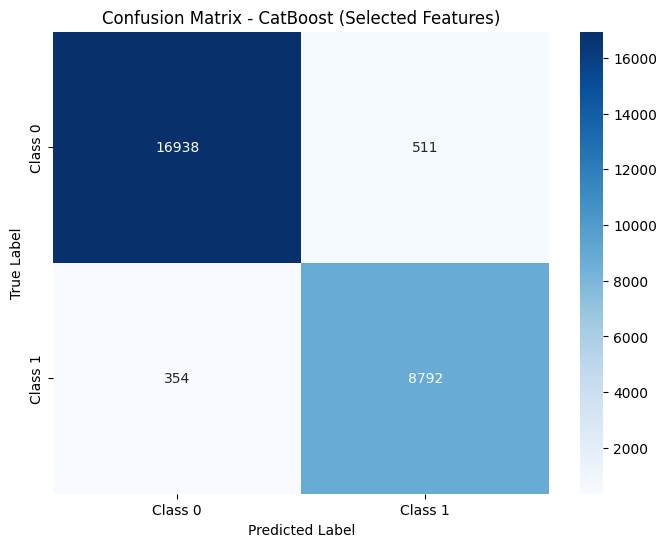

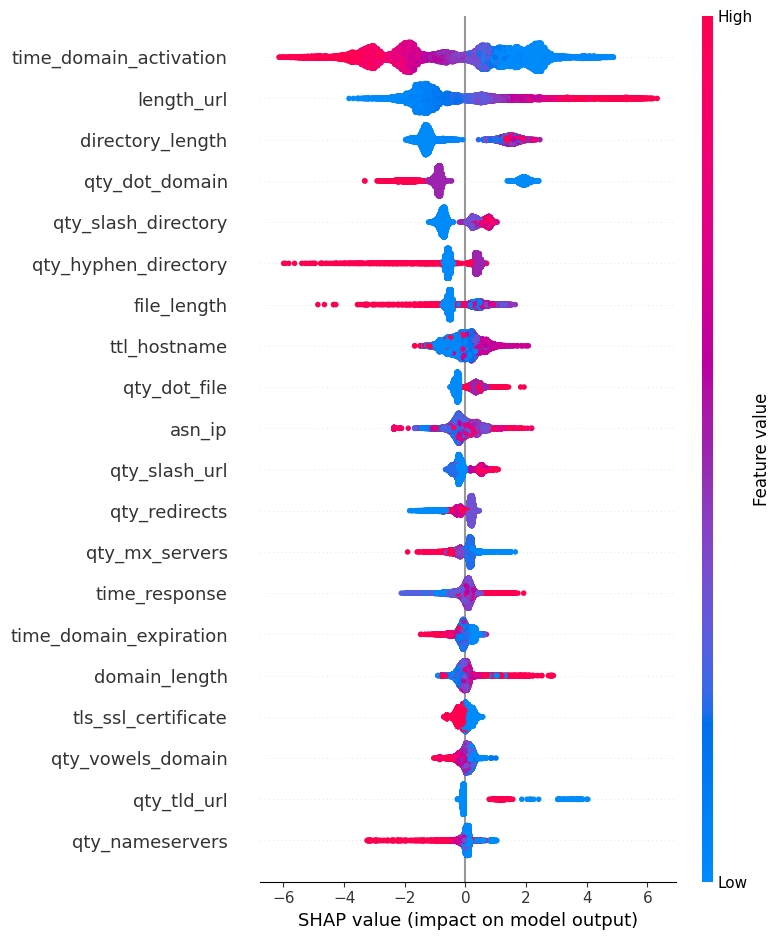

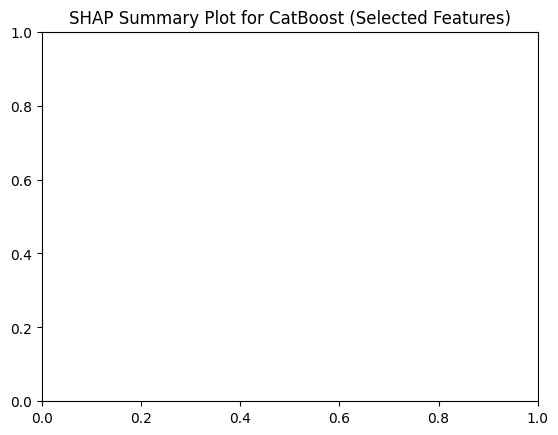

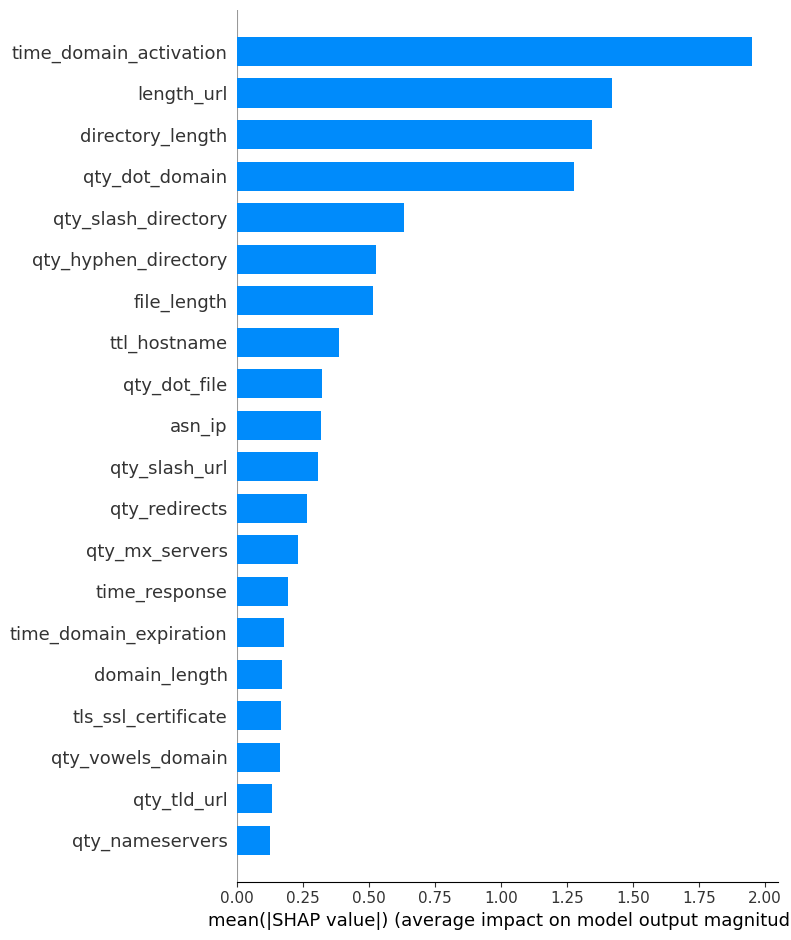

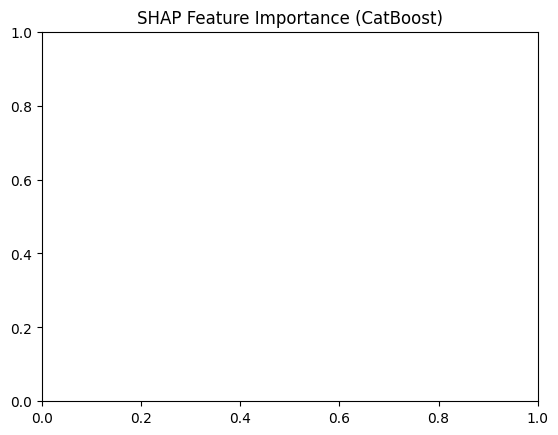

<Figure size 640x480 with 0 Axes>

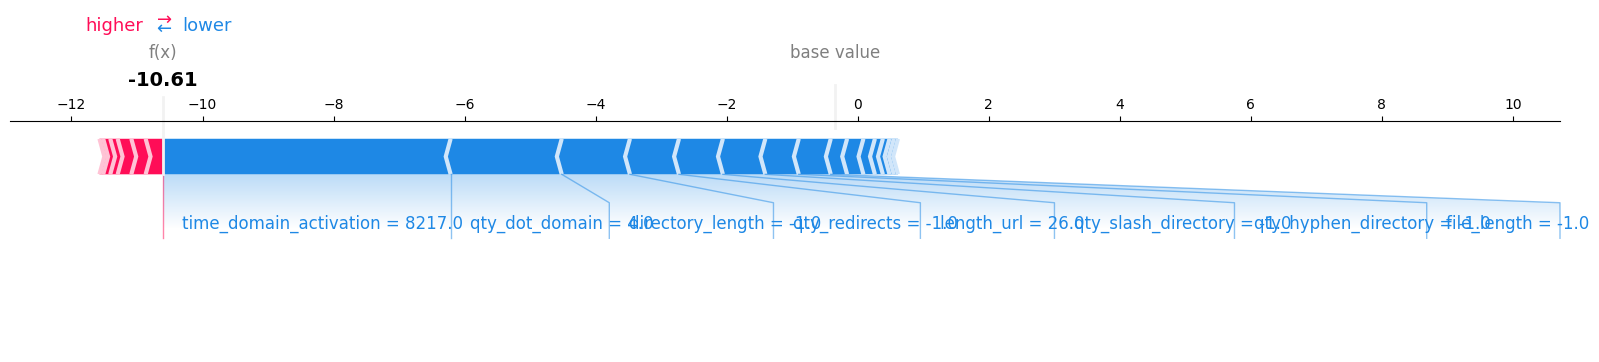

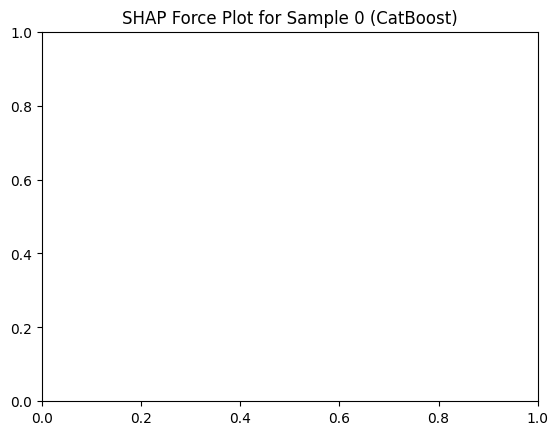

In [36]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_88K112.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using CatBoost
# Train an initial CatBoost model to get feature importances
catboost_initial_model = CatBoostClassifier(random_state=42, silent=True)
catboost_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on CatBoost feature importances
feature_selector = SelectFromModel(catboost_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by CatBoost: {selected_features}")

# Step 6: Train final CatBoost model with selected features
catboost_model = CatBoostClassifier(random_state=42, silent=True)
catboost_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = catboost_model.predict(X_test_selected)
y_proba = catboost_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
catboost_accuracy = accuracy_score(y_test, y_pred)
catboost_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")


print(f"CatBoost Accuracy (Selected Features): {catboost_accuracy}")
print(f"CatBoost ROC-AUC (Selected Features): {catboost_roc_auc}")
print("CatBoost Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - CatBoost (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for CatBoost
# Create a SHAP explainer for CatBoost model
explainer = shap.TreeExplainer(catboost_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for CatBoost (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (CatBoost)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (CatBoost)")
plt.show()


Data types of columns:
url                object
length_url          int64
length_hostname     int64
ip                 object
nb_dots             int64
                    ...  
web_traffic         int64
dns_record          int64
google_index        int64
page_rank           int64
status             object
Length: 89, dtype: object
Before SMOTE: Class distribution in y_train: 0    4022
1    4014
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: 1    4022
0    4022
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by CatBoost: Index(['url', 'length_url', 'length_hostname', 'nb_dots', 'nb_hyphens',
       'nb_qm', 'nb_slash', 'nb_www', 'ratio_digits_url', 'ratio_digits_host',
       'length_words_raw', 'shortest_word_path', 'longest_words_raw',
       'longest_word_path', 'avg_words_raw', 'avg_word_path', 'phish_hints',
       'nb_hyperlinks', 'ratio_extHyperlinks', 'ratio_extRedirection',
       'safe_anchor', 'domain_registration_length', 'domain_age',
       'web_traffic', 'google_index', 'page_rank'],
      dtype='object')
Running time: 9.96728 seconds
CatBoost Accuracy (Selected Features): 0.9820029027576197
CatBoost ROC-AUC (Selected Features): 0.9971560364625919
CatBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1718
           1       0.98      0.98      0.98      1727

    accuracy                           0.98      3445
   macro avg       0.98      0.98      0.98  

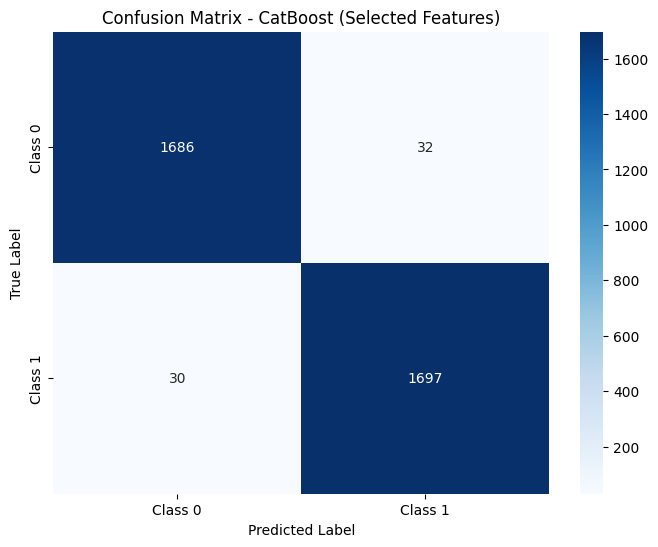

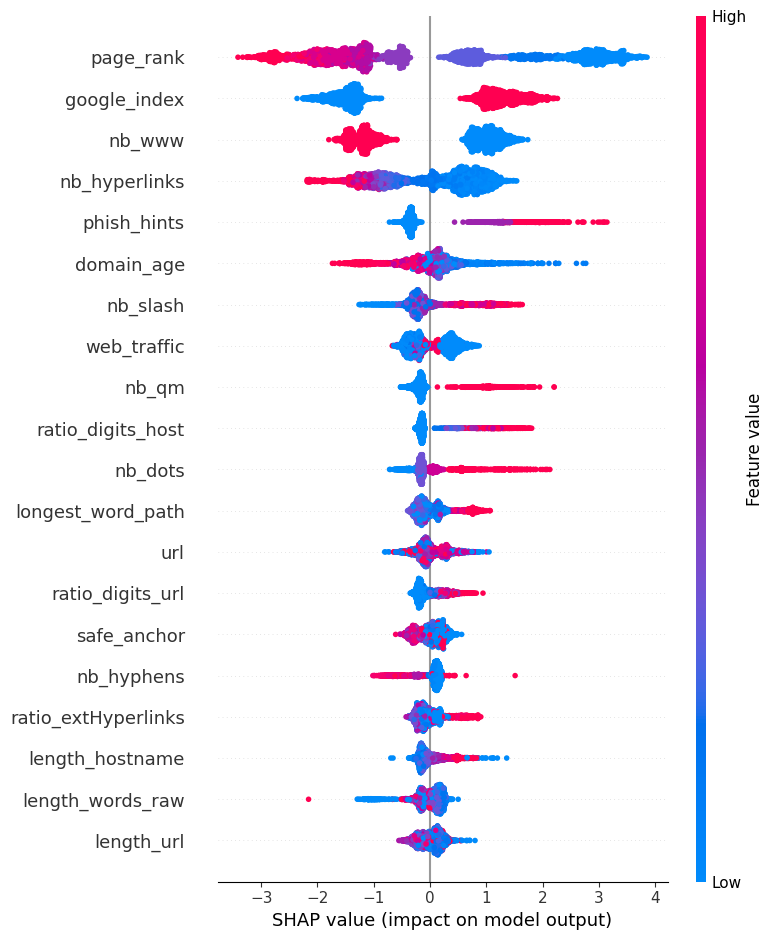

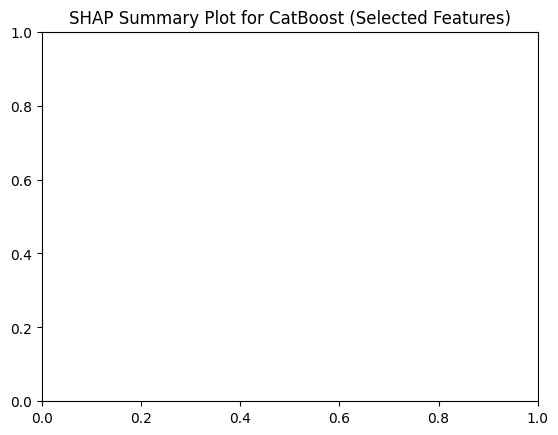

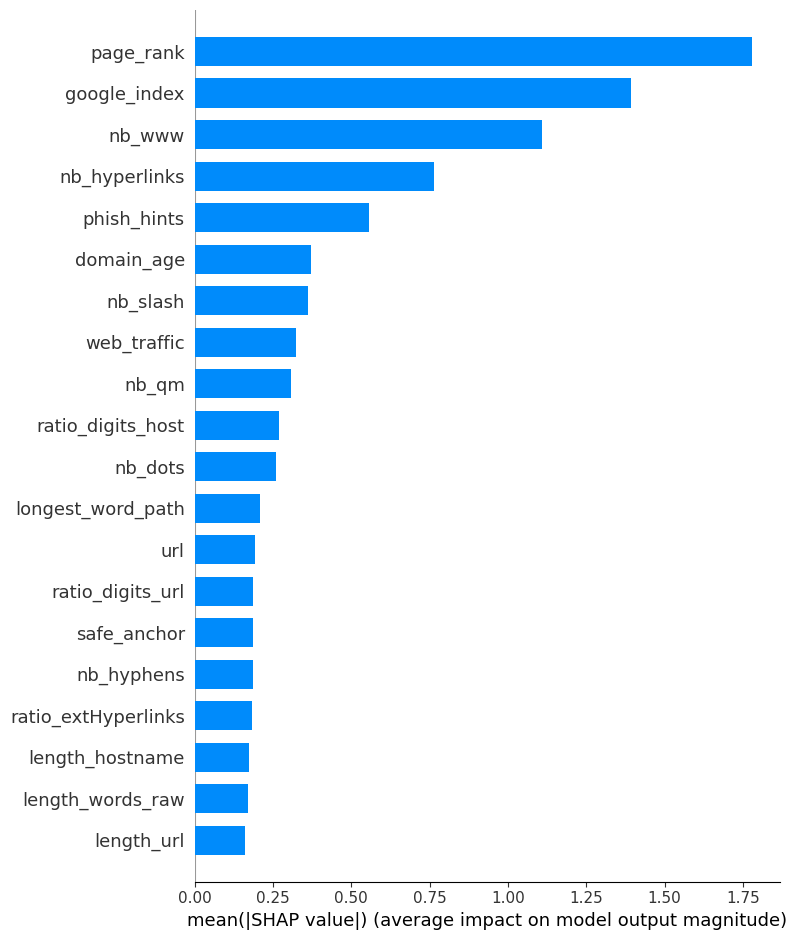

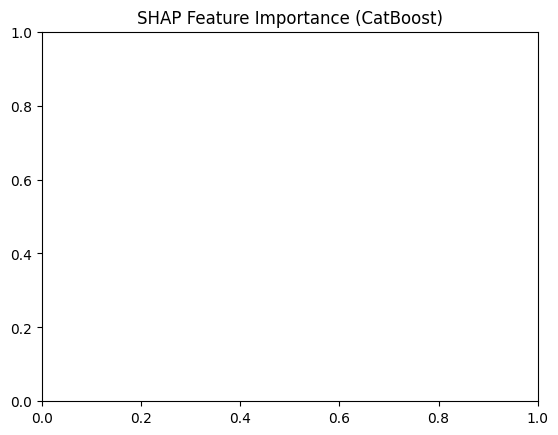

<Figure size 640x480 with 0 Axes>

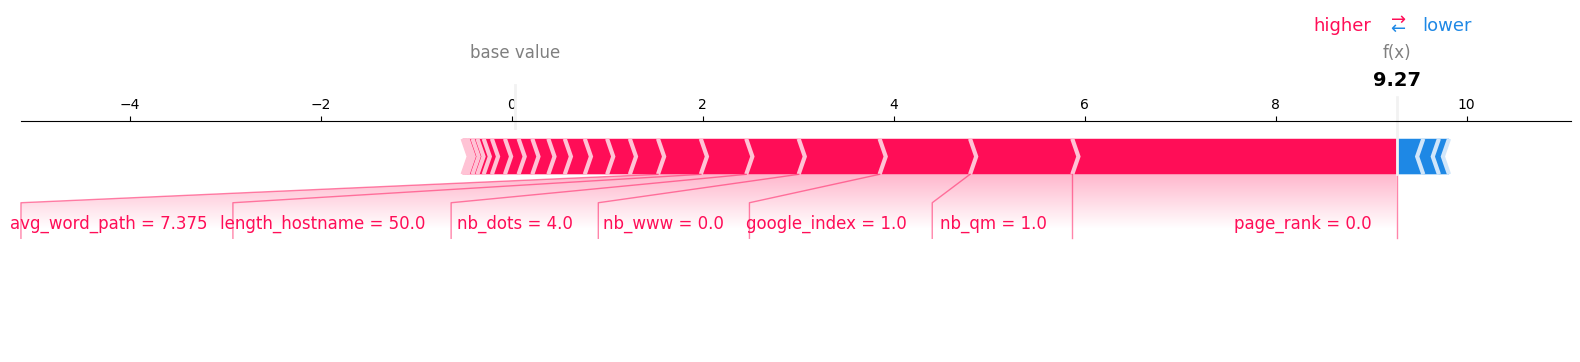

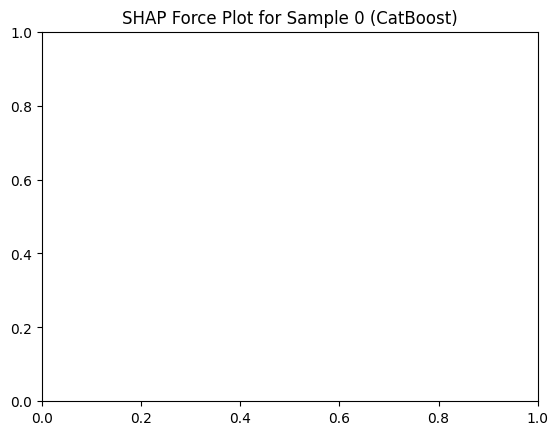

In [48]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_11K89.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using CatBoost
# Train an initial CatBoost model to get feature importances
catboost_initial_model = CatBoostClassifier(random_state=42, silent=True)
catboost_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on CatBoost feature importances
feature_selector = SelectFromModel(catboost_initial_model, threshold="mean", prefit=False)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by CatBoost: {selected_features}")

# Step 6: Train final CatBoost model with selected features
catboost_model = CatBoostClassifier(random_state=42, silent=True)
catboost_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = catboost_model.predict(X_test_selected)
y_proba = catboost_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
catboost_accuracy = accuracy_score(y_test, y_pred)
catboost_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")


print(f"CatBoost Accuracy (Selected Features): {catboost_accuracy}")
print(f"CatBoost ROC-AUC (Selected Features): {catboost_roc_auc}")
print("CatBoost Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - CatBoost (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for CatBoost
# Create a SHAP explainer for CatBoost model
explainer = shap.TreeExplainer(catboost_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for CatBoost (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (CatBoost)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (CatBoost)")
plt.show()


Data types of columns:
index                          int64
having_IPhaving_IP_Address     int64
URLURL_Length                  int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic    

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by CatBoost: Index(['Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Request_URL',
       'URL_of_Anchor', 'Links_in_tags', 'SFH', 'age_of_domain', 'web_traffic',
       'Links_pointing_to_page'],
      dtype='object')
Running time: 6.73098 seconds
CatBoost Accuracy (Selected Features): 0.9478444377449503
CatBoost ROC-AUC (Selected Features): 0.9902983956949641
CatBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1428
           1       0.95      0.95      0.95      1889

    accuracy                           0.95      3317
   macro avg       0.95      0.95      0.95      3317
weighted avg       0.95      0.95      0.95      3317



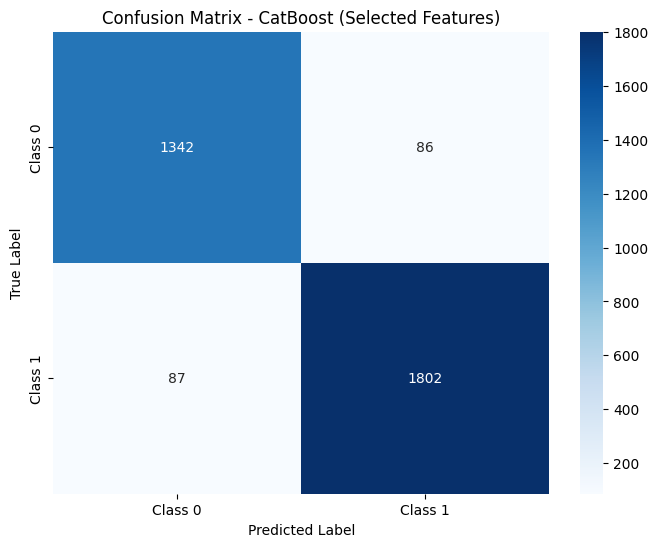

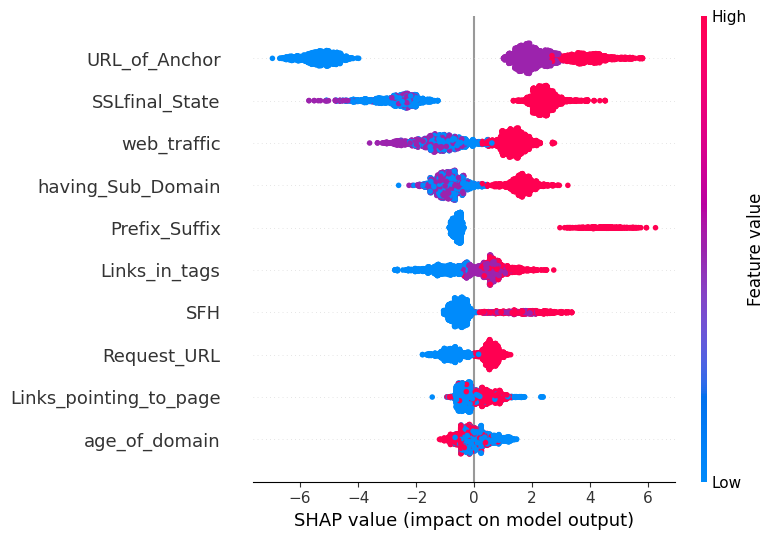

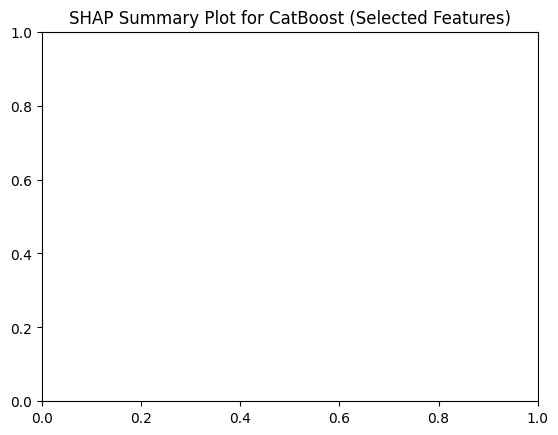

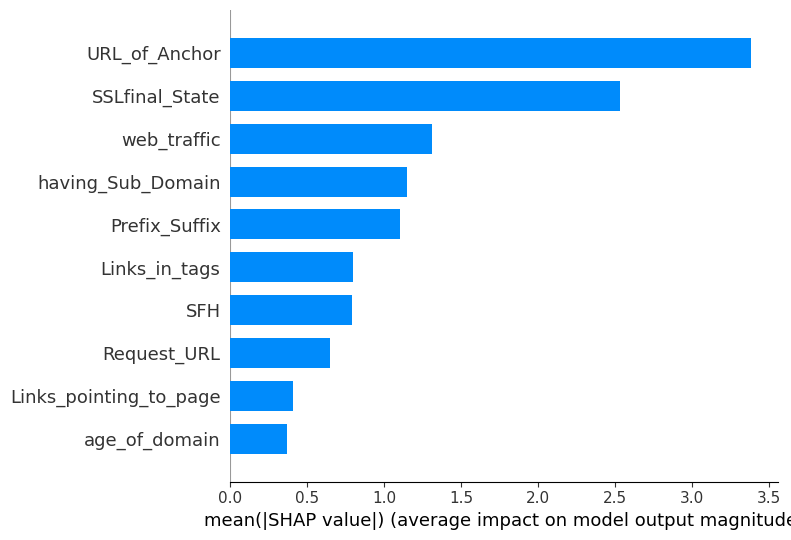

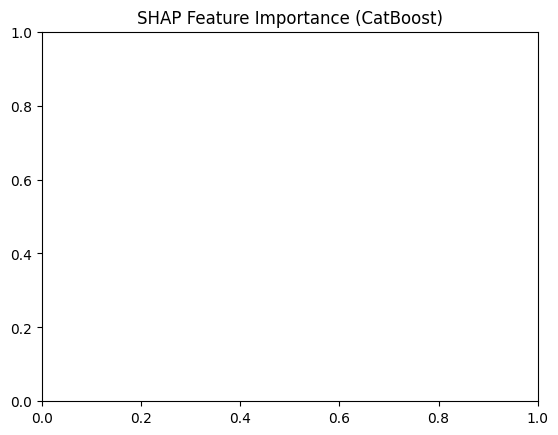

<Figure size 640x480 with 0 Axes>

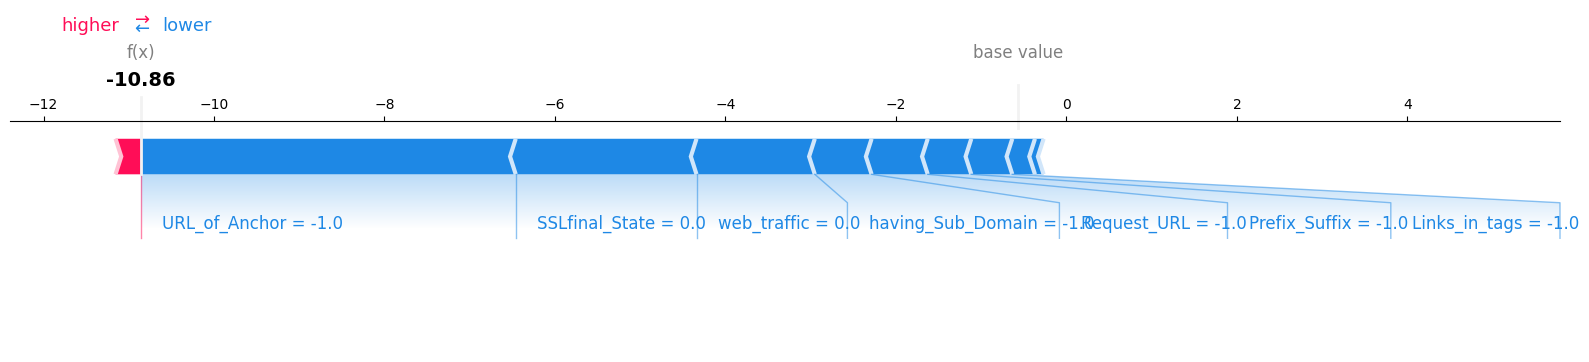

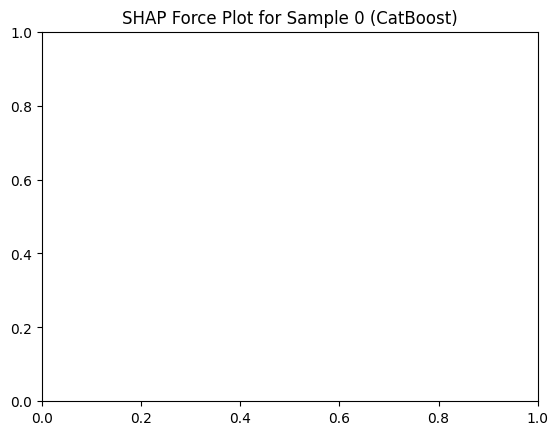

In [54]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_11055.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,2:]

X = X1.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using CatBoost
# Train an initial CatBoost model to get feature importances
catboost_initial_model = CatBoostClassifier(random_state=42, silent=True)
catboost_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on CatBoost feature importances
feature_selector = SelectFromModel(catboost_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by CatBoost: {selected_features}")

# Step 6: Train final CatBoost model with selected features
catboost_model = CatBoostClassifier(random_state=42, silent=True)
catboost_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = catboost_model.predict(X_test_selected)
y_proba = catboost_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
catboost_accuracy = accuracy_score(y_test, y_pred)
catboost_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")


print(f"CatBoost Accuracy (Selected Features): {catboost_accuracy}")
print(f"CatBoost ROC-AUC (Selected Features): {catboost_roc_auc}")
print("CatBoost Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - CatBoost (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for CatBoost
# Create a SHAP explainer for CatBoost model
explainer = shap.TreeExplainer(catboost_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for CatBoost (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (CatBoost)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (CatBoost)")
plt.show()


Data types of columns:
num_dots_url            int64
num_hyph_url            int64
num_underline_url       int64
num_slash_url           int64
num_questionmark_url    int64
                        ...  
num_percent_param       int64
length_param            int64
tld_in_param            int64
num_param               int64
phishing                int64
Length: 75, dtype: object
Before SMOTE: Class distribution in y_train: 0    3515
1    3485
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: 0    3515
1    3515
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by CatBoost: Index(['num_slash_url', 'length_url', 'num_dots_dom', 'num_hyph_dom',
       'num_vowels_dom', 'length_dom', 'num_hyph_path', 'num_slash_path',
       'length_path', 'length_file'],
      dtype='object')
Running time: 7.82146 seconds
CatBoost Accuracy (Selected Features): 0.8956666666666667
CatBoost ROC-AUC (Selected Features): 0.9581424809147582
CatBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1485
           1       0.91      0.89      0.90      1515

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



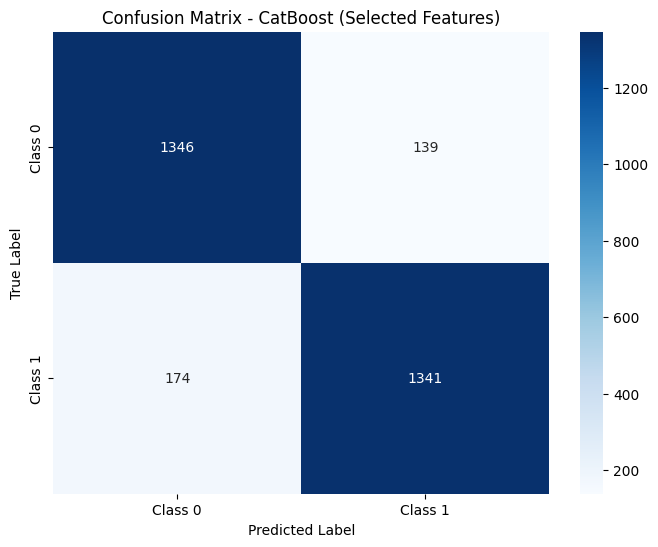

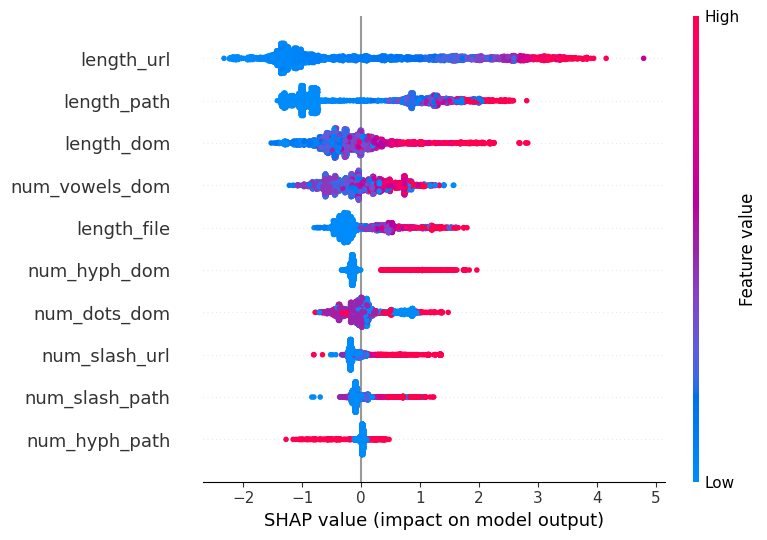

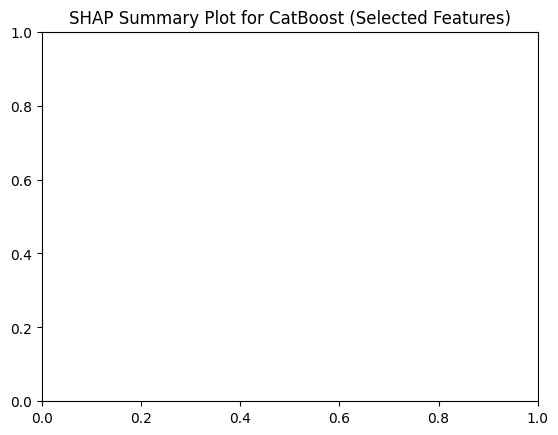

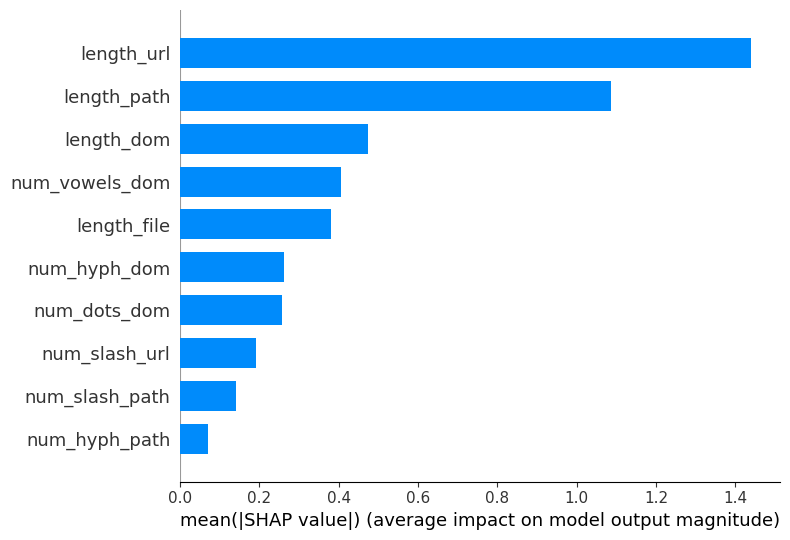

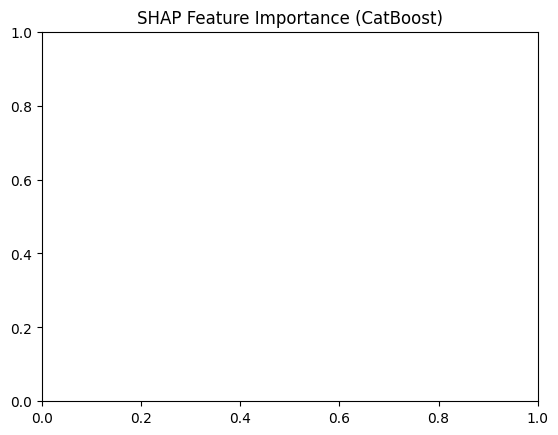

<Figure size 640x480 with 0 Axes>

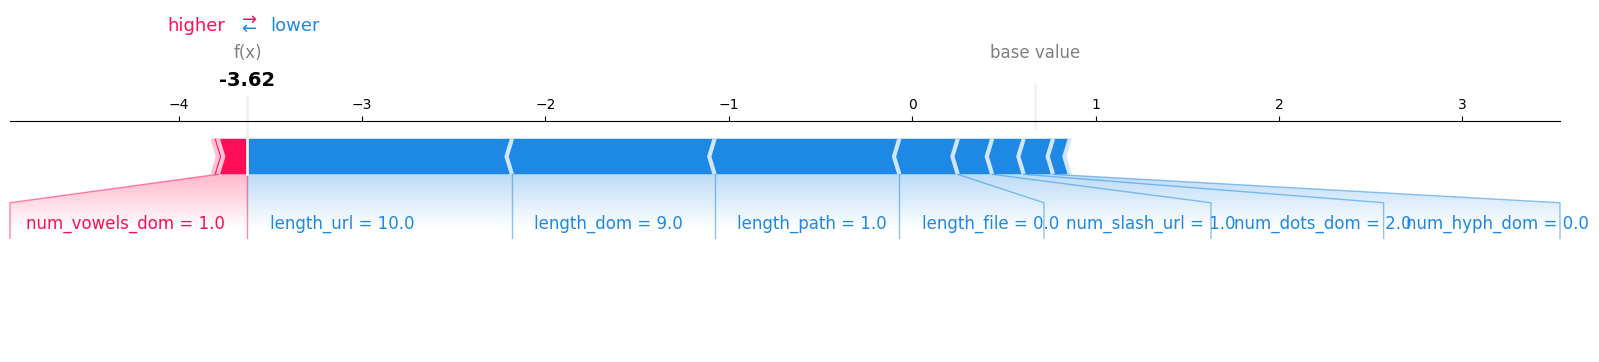

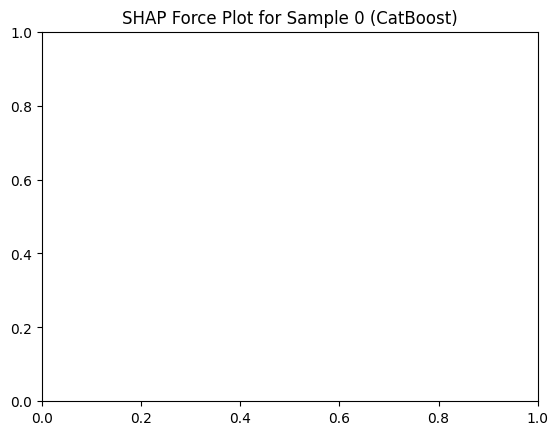

In [56]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_10K75.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,2:]

X = X1.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using CatBoost
# Train an initial CatBoost model to get feature importances
catboost_initial_model = CatBoostClassifier(random_state=42, silent=True)
catboost_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on CatBoost feature importances
feature_selector = SelectFromModel(catboost_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by CatBoost: {selected_features}")

# Step 6: Train final CatBoost model with selected features
catboost_model = CatBoostClassifier(random_state=42, silent=True)
catboost_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = catboost_model.predict(X_test_selected)
y_proba = catboost_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
catboost_accuracy = accuracy_score(y_test, y_pred)
catboost_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")


print(f"CatBoost Accuracy (Selected Features): {catboost_accuracy}")
print(f"CatBoost ROC-AUC (Selected Features): {catboost_roc_auc}")
print("CatBoost Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - CatBoost (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for CatBoost
# Create a SHAP explainer for CatBoost model
explainer = shap.TreeExplainer(catboost_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for CatBoost (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (CatBoost)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (CatBoost)")
plt.show()


Data types of columns:
id                                      int64
NumDots                                 int64
SubdomainLevel                          int64
PathLevel                               int64
UrlLength                               int64
NumDash                                 int64
NumDashInHostname                       int64
AtSymbol                                int64
TildeSymbol                             int64
NumUnderscore                           int64
NumPercent                              int64
NumQueryComponents                      int64
NumAmpersand                            int64
NumHash                                 int64
NumNumericChars                         int64
NoHttps                                 int64
RandomString                            int64
IpAddress                               int64
DomainInSubdomains                      int64
DomainInPaths                           int64
HttpsInHostname                         int64
HostnameLen

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by CatBoost: Index(['PathLevel', 'NumDash', 'NumNumericChars', 'PctExtHyperlinks',
       'PctExtResourceUrls', 'ExtFavicon', 'InsecureForms',
       'PctNullSelfRedirectHyperlinks', 'FrequentDomainNameMismatch',
       'SubmitInfoToEmail', 'IframeOrFrame', 'ExtMetaScriptLinkRT',
       'PctExtNullSelfRedirectHyperlinksRT'],
      dtype='object')
Running time: 7.81977 seconds
CatBoost Accuracy (Selected Features): 0.98
CatBoost ROC-AUC (Selected Features): 0.996921015497874
CatBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1463
           1       0.98      0.98      0.98      1537

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



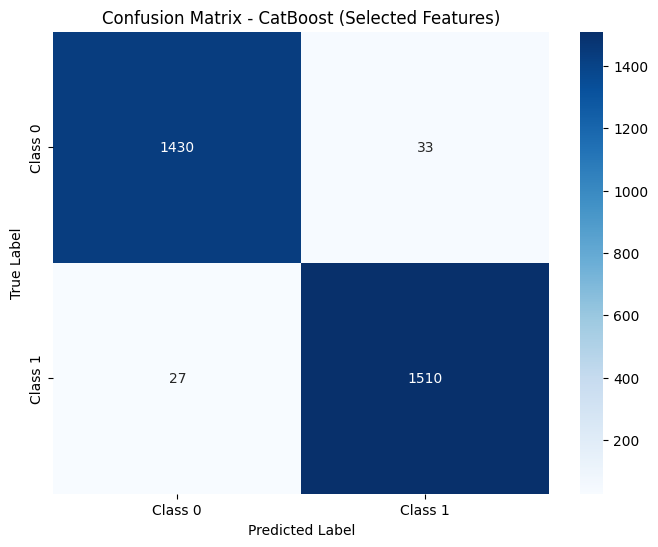

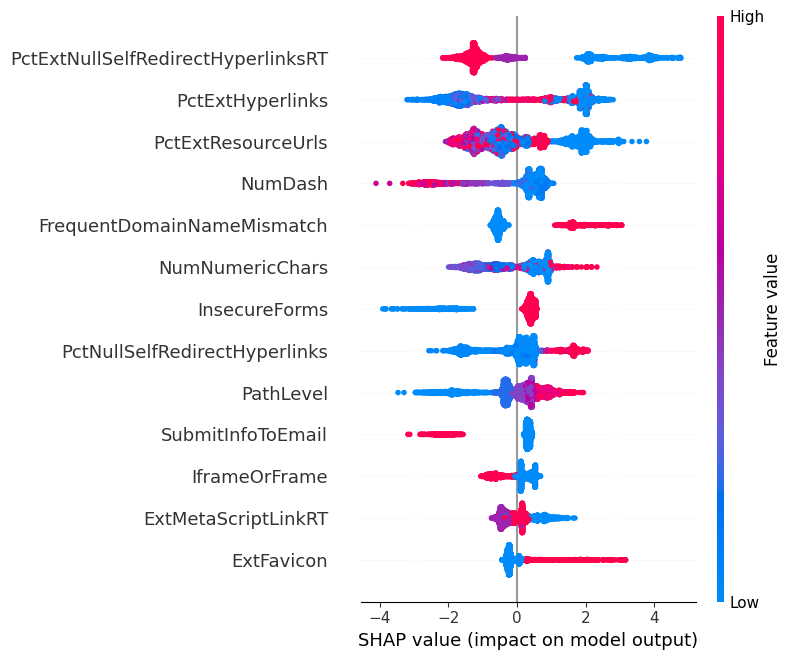

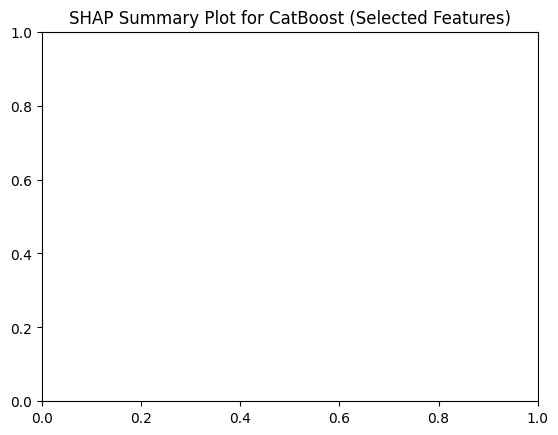

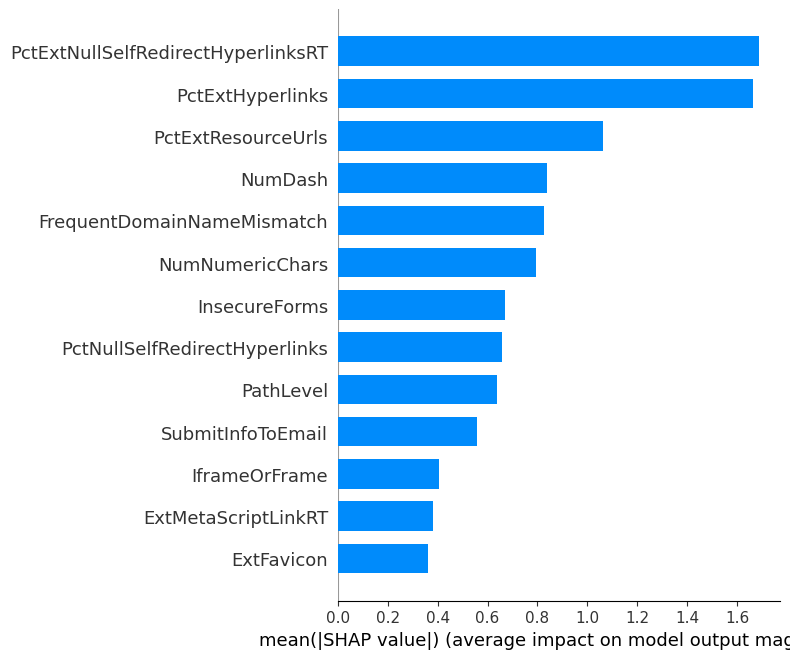

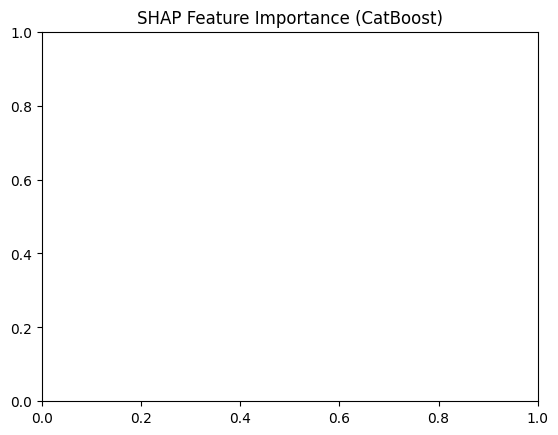

<Figure size 640x480 with 0 Axes>

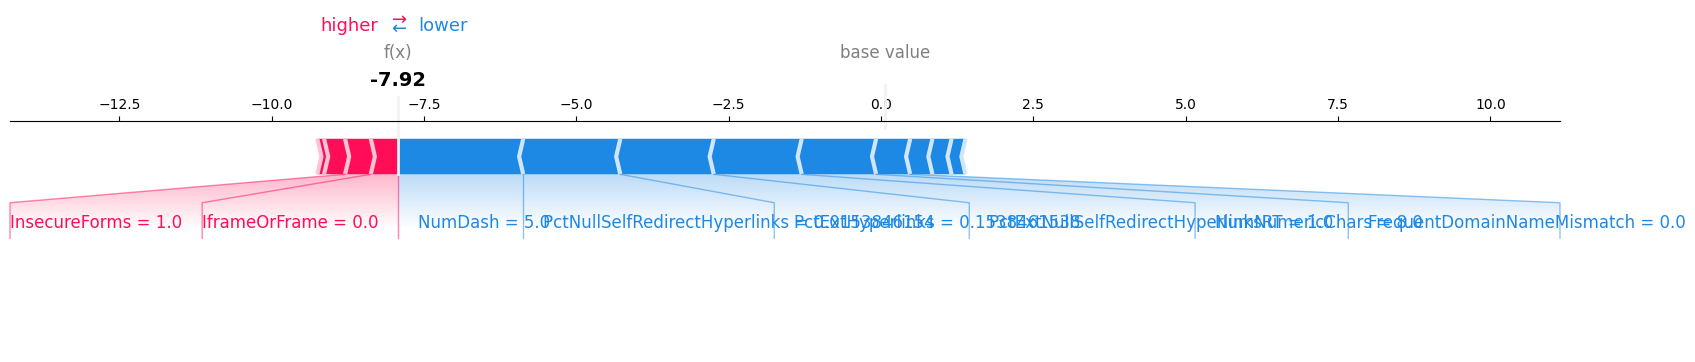

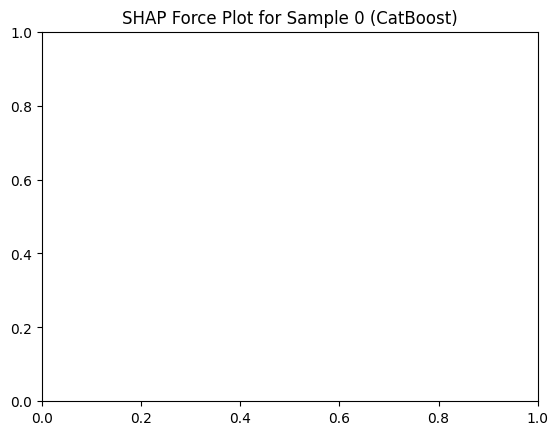

In [62]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_10K50.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
X1=df.iloc[:,2:]

X = X1.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using CatBoost
# Train an initial CatBoost model to get feature importances
catboost_initial_model = CatBoostClassifier(random_state=42, silent=True)
catboost_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on CatBoost feature importances
feature_selector = SelectFromModel(catboost_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by CatBoost: {selected_features}")

# Step 6: Train final CatBoost model with selected features
catboost_model = CatBoostClassifier(random_state=42, silent=True)
catboost_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = catboost_model.predict(X_test_selected)
y_proba = catboost_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
catboost_accuracy = accuracy_score(y_test, y_pred)
catboost_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")


print(f"CatBoost Accuracy (Selected Features): {catboost_accuracy}")
print(f"CatBoost ROC-AUC (Selected Features): {catboost_roc_auc}")
print("CatBoost Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - CatBoost (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for CatBoost
# Create a SHAP explainer for CatBoost model
explainer = shap.TreeExplainer(catboost_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for CatBoost (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (CatBoost)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (CatBoost)")
plt.show()


Data types of columns:
Domain           object
Have_IP           int64
Have_At           int64
URL_Length        int64
URL_Depth         int64
Redirection       int64
https_Domain      int64
TinyURL           int64
Prefix/Suffix     int64
DNS_Record        int64
Web_Traffic       int64
Domain_Age        int64
Domain_End        int64
iFrame            int64
Mouse_Over        int64
Right_Click       int64
Web_Forwards      int64
Label             int64
dtype: object
Before SMOTE: Class distribution in y_train: 1    3537
0    3463
Name: count, dtype: int64
After SMOTE: Class distribution in y_train_resampled: 1    3537
0    3537
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by CatBoost: Index(['Domain', 'URL_Length', 'URL_Depth'], dtype='object')
Running time: 7.45641 seconds
CatBoost Accuracy (Selected Features): 0.9166666666666666
CatBoost ROC-AUC (Selected Features): 0.9739452582482409
CatBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1537
           1       0.96      0.87      0.91      1463

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



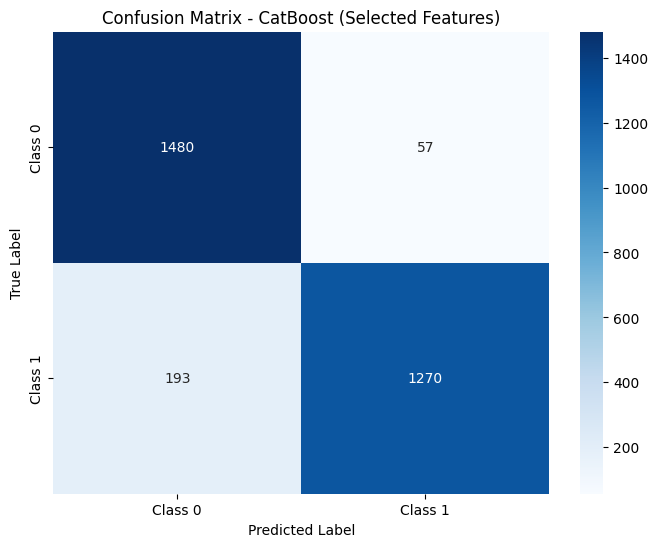

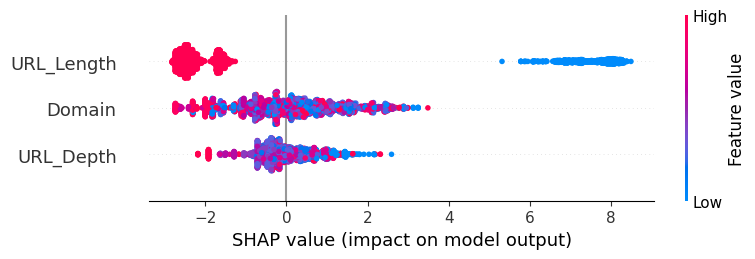

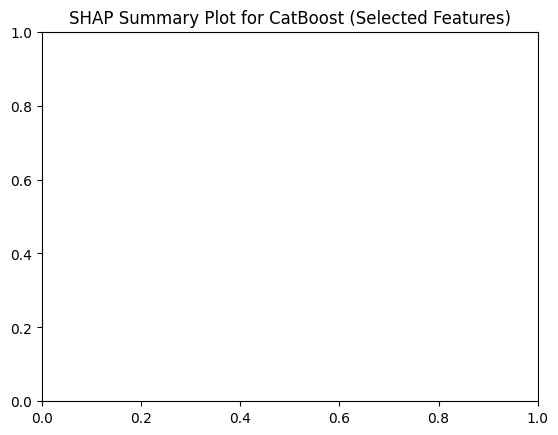

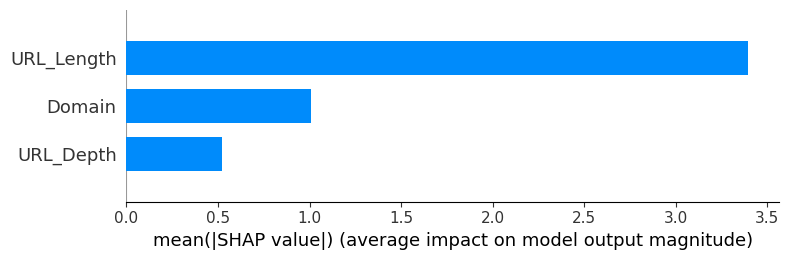

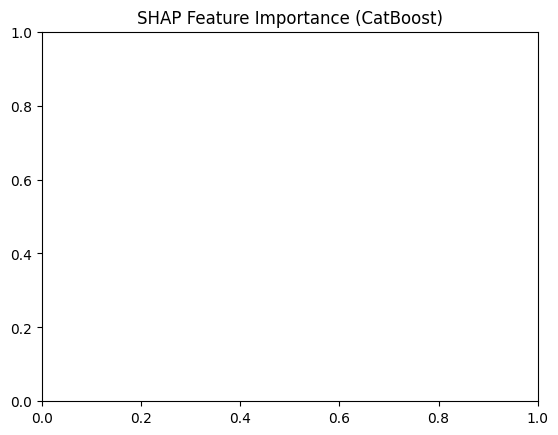

<Figure size 640x480 with 0 Axes>

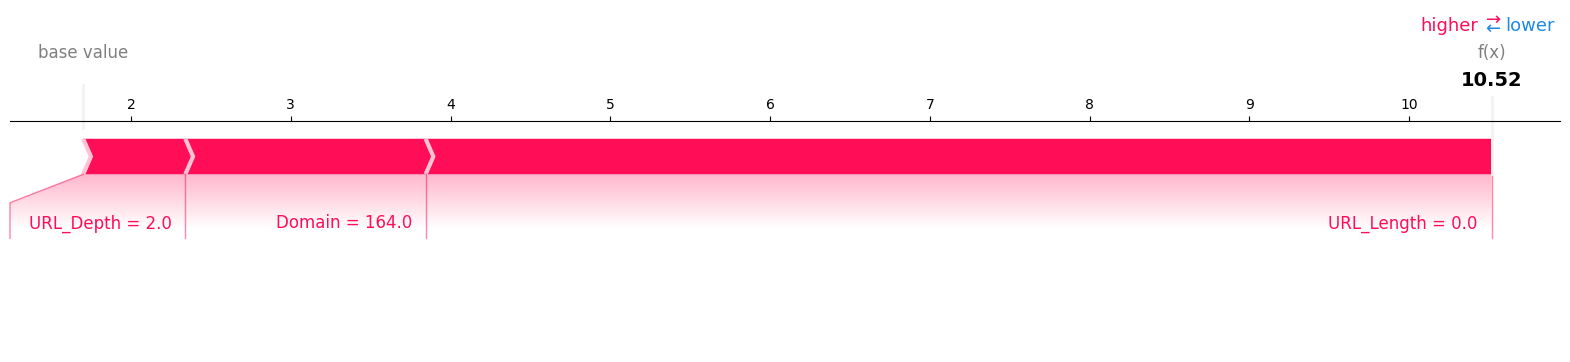

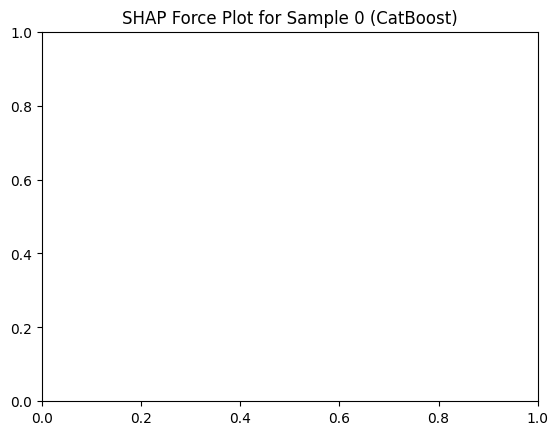

In [64]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import time

start_time = time.time()
# Step 1: Load dataset
df = pd.read_csv('ds_10K18.csv')

# Step 2: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Separate features (X) and target (y)
#X1=df.iloc[:,2:]

X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode non-numeric columns
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target label if it is categorical
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Step 3: Map class labels if necessary to ensure they are 0 and 1
# Replace -1 with 0 if the labels are binary and include -1
y = np.where(y == -1, 0, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Handle imbalance in target using SMOTE
print("Before SMOTE: Class distribution in y_train:", pd.Series(y_train).value_counts())

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE, replace -1 with 0 in case the labels changed during resampling
y_train_resampled = np.where(y_train_resampled == -1, 0, y_train_resampled)

print("After SMOTE: Class distribution in y_train_resampled:", pd.Series(y_train_resampled).value_counts())

# Step 5: Feature selection using CatBoost
# Train an initial CatBoost model to get feature importances
catboost_initial_model = CatBoostClassifier(random_state=42, silent=True)
catboost_initial_model.fit(X_train_resampled, y_train_resampled)

# Use SelectFromModel for feature selection based on CatBoost feature importances
feature_selector = SelectFromModel(catboost_initial_model, threshold="mean", prefit=True)
X_train_selected = feature_selector.transform(X_train_resampled)
X_test_selected = feature_selector.transform(X_test)
selected_features = X.columns[feature_selector.get_support()]

print(f"Selected features by CatBoost: {selected_features}")

# Step 6: Train final CatBoost model with selected features
catboost_model = CatBoostClassifier(random_state=42, silent=True)
catboost_model.fit(X_train_selected, y_train_resampled)

# Step 7: Predict and evaluate model
y_pred = catboost_model.predict(X_test_selected)
y_proba = catboost_model.predict_proba(X_test_selected)[:, 1]

# Calculate performance metrics
catboost_accuracy = accuracy_score(y_test, y_pred)
catboost_roc_auc = roc_auc_score(y_test, y_proba)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Running time: {elapsed_time:.5f} seconds")


print(f"CatBoost Accuracy (Selected Features): {catboost_accuracy}")
print(f"CatBoost ROC-AUC (Selected Features): {catboost_roc_auc}")
print("CatBoost Classification Report (Selected Features):")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix visualization
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - CatBoost (Selected Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: SHAP Analysis for CatBoost
# Create a SHAP explainer for CatBoost model
explainer = shap.TreeExplainer(catboost_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_selected)

# Summary plot for SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features)
plt.title("SHAP Summary Plot for CatBoost (Selected Features)")

# Feature importance plot using SHAP values
plt.figure()
shap.summary_plot(shap_values, X_test_selected, feature_names=selected_features, plot_type="bar")
plt.title("SHAP Feature Importance (CatBoost)")

# Individual feature explanation using SHAP for a single sample
# Here we show the first sample from the test set
sample_index = 0
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], X_test_selected[sample_index, :], feature_names=selected_features, matplotlib=True)
plt.title(f"SHAP Force Plot for Sample {sample_index} (CatBoost)")
plt.show()
